# 데이터 분석 미니 프로젝트

## 지역 인구 데이터

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [3]:
# 한글 폰트 설정
import platform

from matplotlib import rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Linux':
    rc('font', family = 'NanumGothic')  # 또는 '나눔고딕'
    print('Linux system... font set to NanumGothic')
elif platform.system() == 'Windows':
    rc('font', family = 'Malgun Gothic')   # 또는 '맑은 고딕'
    print('Windows system... font set to Malgun Gothic')
else:
    print('Unknown system... sorry~~~~')

Linux system... font set to NanumGothic


In [38]:
df_population = pd.read_csv('./pop_data/population.csv', encoding='cp949', thousands=',')
df_population_change = pd.read_csv('./pop_data/population_change.csv', encoding='cp949', thousands=',')
df_population_by_age = pd.read_csv('./pop_data/population_by_age.csv', encoding='cp949', thousands=',')

### 인구수

In [24]:
df_population.head()

,행정구역,2020년_총인구수,2020년_세대수,2020년_세대당 인구,2020년_남자 인구수,2020년_여자 인구수,2020년_남여 비율,2021년_총인구수,2021년_세대수,2021년_세대당 인구,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_총인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
0,경기도 경기도 용인시 (4146000000),1074176,420519,2.55,532847,541329,0.98,1077508.0,429492.0,2.51,...,2.45,538049.0,547815.0,0.98,1091186.0,448730.0,2.43,540342.0,550844.0,0.98
1,경기도 경기도 용인시 처인구 (4146100000),257498,111684,2.31,131974,125524,1.05,260198.0,115048.0,2.26,...,2.19,140423.0,133739.0,1.05,282044.0,129138.0,2.18,144280.0,137764.0,1.05
2,경기도 용인시 처인구 포곡읍(4146125000),33300,14372,2.32,17230,16070,1.07,33495.0,14592.0,2.30,...,2.21,16189.0,15111.0,1.07,30848.0,14128.0,2.18,15939.0,14909.0,1.07
3,경기도 용인시 처인구 모현읍(4146125300),26202,11783,2.22,13729,12473,1.10,27119.0,12407.0,2.19,...,2.11,14349.0,13180.0,1.09,34384.0,15822.0,2.17,17726.0,16658.0,1.06
4,경기도 용인시 처인구 이동읍(4146125600),20265,8796,2.30,10372,9893,1.05,20446.0,9057.0,2.26,...,2.16,10029.0,9435.0,1.06,19018.0,8921.0,2.13,9773.0,9245.0,1.06


In [25]:
df_population.columns.unique()

Index(['행정구역', '2020년_총인구수', '2020년_세대수', '2020년_세대당 인구', '2020년_남자 인구수',
       '2020년_여자 인구수', '2020년_남여 비율', '2021년_총인구수', '2021년_세대수',
       '2021년_세대당 인구', '2021년_남자 인구수', '2021년_여자 인구수', '2021년_남여 비율',
       '2022년_총인구수', '2022년_세대수', '2022년_세대당 인구', '2022년_남자 인구수',
       '2022년_여자 인구수', '2022년_남여 비율', '2023년_총인구수', '2023년_세대수',
       '2023년_세대당 인구', '2023년_남자 인구수', '2023년_여자 인구수', '2023년_남여 비율',
       '2024년_총인구수', '2024년_세대수', '2024년_세대당 인구', '2024년_남자 인구수',
       '2024년_여자 인구수', '2024년_남여 비율', '2025년_총인구수', '2025년_세대수',
       '2025년_세대당 인구', '2025년_남자 인구수', '2025년_여자 인구수', '2025년_남여 비율'],
      dtype='str')

In [26]:
# 컬럼 양옆 공백 제거
df_population.columns = df_population.columns.str.strip()
df_population_by_age = df_population_by_age.columns.str.strip()
df_population_change = df_population_change.columns.str.strip()

In [27]:
# 행정구역을 index로 한 dataframe
df_population_dist = df_population.set_index('행정구역')

In [ ]:
# 경기도 용인시 총 인구수
total_population = df_population_dist.loc['경기도 경기도 용인시 (4146000000)'].filter(like='총인구수')

# 불편한 컬럼을 연도/총인구수로 보기 편하게
total_population = total_population.rename_axis('연도').reset_index(name='총인구수')

# 2020년_총인구수 와 같은 포맷에서 숫자(연도)만 추출
total_population['연도'] = total_population['연도'].str.extract(r'(\d{4})').astype(int)

total_population

,연도,총인구수
0,2020,1074176.0
1,2021,1077508.0
2,2022,1074971.0
3,2023,1075566.0
4,2024,1085864.0
5,2025,1091186.0


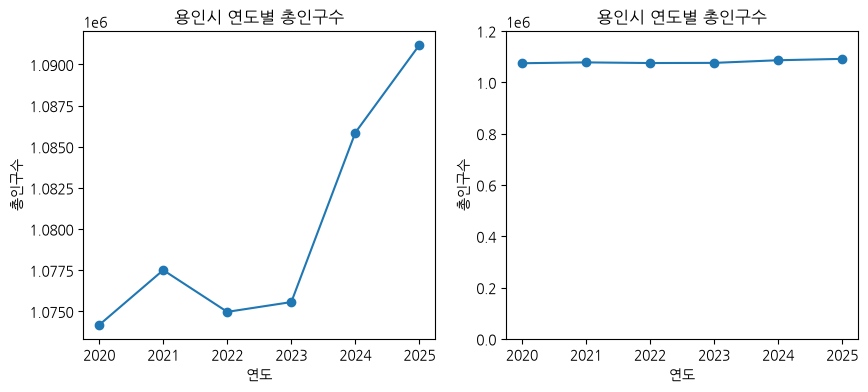

In [ ]:
plt.figure( figsize= (10, 4) )

plt.subplot(1, 2, 1)
plt.plot(
    total_population['연도'],
    total_population['총인구수'],
    marker='o'
)

plt.xlabel('연도')
plt.ylabel('총인구수')
plt.title('용인시 연도별 총인구수')

plt.subplot(1, 2, 2)
plt.plot(
    total_population['연도'],
    total_population['총인구수'],
    marker='o'
)

# y축이 0부터 시작  # 이게 없으면 적은 증감으로도 드라마틱한 수치 변화처럼 보인다
plt.ylim(0, 1_200_000)

plt.xlabel('연도')
plt.ylabel('총인구수')
plt.title('용인시 연도별 총인구수')

plt.show()

[분석]
- 인구가 꾸준히 증가하다 2022년에 감소하였고, 2024년에 다시 큰 폭으로 증가함
- 그래프의 기준점이나 시작점을 어디에 두느냐에 따라 그래프의 모양에 큰 차이가 발생함 -> 시각화가 만능은 아니니 객관적으로 판단할 수 있는 능력이 필요

### 인구증감

In [ ]:
# 행정구역을 index로 한 df
df_population_change_dist = df_population_change.set_index('행정구역')

,2020년_전년인구수_남자인구수,2020년_전년인구수_여자인구수,2020년_전년인구수_계,2020년_당년인구수_남자인구수,2020년_당년인구수_여자인구수,2020년_당년인구수_계,2020년_인구증감_남자인구수,2020년_인구증감_여자인구수,2020년_인구증감_계,2021년_전년인구수_남자인구수,...,2024년_인구증감_계,2025년_전년인구수_남자인구수,2025년_전년인구수_여자인구수,2025년_전년인구수_계,2025년_당년인구수_남자인구수,2025년_당년인구수_여자인구수,2025년_당년인구수_계,2025년_인구증감_남자인구수,2025년_인구증감_여자인구수,2025년_인구증감_계
행정구역,,,,,,,,,,,,,,,,,,,,,
경기도 용인시 (4146000000),525946,533663,1059609,532847,541329,1074176,6901,7666,14567,532847,...,10298,538049,547815,1085864,540342,550844,1091186,2293,3029,5322
경기도 용인시 처인구 (4146100000),130034,123862,253896,131974,125524,257498,1940,1662,3602,131974,...,12674,140423,133739,274162,144280,137764,282044,3857,4025,7882
경기도 용인시 처인구 포곡읍(4146125000),17023,15927,32950,17230,16070,33300,207,143,350,17230,...,-1580,16189,15111,31300,15939,14909,30848,-250,-202,-452
경기도 용인시 처인구 모현읍(4146125300),13483,12254,25737,13729,12473,26202,246,219,465,13729,...,1242,14349,13180,27529,17726,16658,34384,3377,3478,6855
경기도 용인시 처인구 이동읍(4146125600),10306,9870,20176,10372,9893,20265,66,23,89,10372,...,-602,10029,9435,19464,9773,9245,19018,-256,-190,-446


In [43]:
# 용인시의 연도별 인구증감 데이터 추출
population_change = (df_population_change_dist.loc['경기도 용인시 (4146000000)'].filter(like='인구증감_계'))
population_change

2020년_인구증감_계    14567
2021년_인구증감_계     3332
2022년_인구증감_계    -2537
2023년_인구증감_계      595
2024년_인구증감_계    10298
2025년_인구증감_계     5322
Name: 경기도 용인시 (4146000000), dtype: int64

In [44]:
# 컬럼을 보기 편하도록
population_change = (population_change.rename_axis('연도').reset_index(name='인구증감'))

# '2020년_인구증감_계' → 2020
population_change['연도'] = (population_change['연도'].str.extract(r'(\d{4})').astype(int))

# '14,567' → 14567
population_change['인구증감'] = pd.to_numeric(population_change['인구증감'].astype(str).str.replace(',', '', regex=False))

population_change

,연도,인구증감
0,2020,14567
1,2021,3332
2,2022,-2537
3,2023,595
4,2024,10298
5,2025,5322


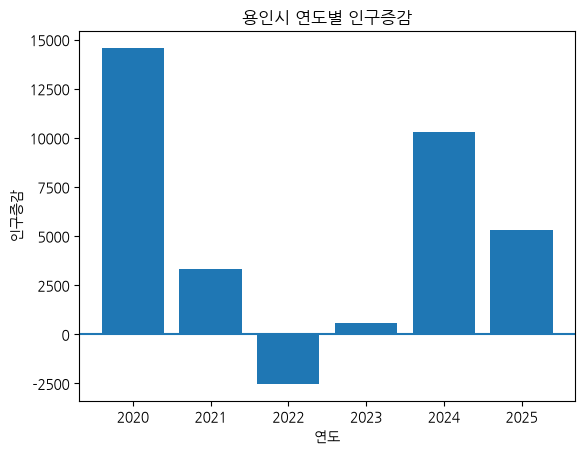

In [ ]:
# 인구증감 bar차트
plt.bar(
    population_change['연도'],
    population_change['인구증감']
)

# 0 기준으로 선을 그어 보기 편하게
plt.axhline(0)

plt.xlabel('연도')
plt.ylabel('인구증감')
plt.title('용인시 연도별 인구증감')

plt.show()

[분석]
- 인구 그래프에서 했던 분석과 마찬가지로 2022년에 인구가 감소했으며, 2023년에는 소폭 성장, 2024년에는 큰 폭으로 성장함
- 2022년, 2024년에 시행 된 정책들을 분석해 볼 필요가 있음

### 연령별 인구

In [66]:
# 행정구역을 index로 한 df
df_age = df_population_by_age.set_index('행정구역')

age_population_2020 = df_age.loc['경기도 용인시 (4146000000)'].filter(regex=r'^2020년_계_.*세$')

# 비교 대상인 2025년 전체(계) 연령별 컬럼만 선택
age_population = df_age.loc['경기도 용인시 (4146000000)'].filter(regex=r'^2025년_계_.*세$')

age_population

2025년_계_0~9세       72561
2025년_계_10~19세    120967
2025년_계_20~29세    127343
2025년_계_30~39세    137917
2025년_계_40~49세    181259
2025년_계_50~59세    192022
2025년_계_60~69세    133792
2025년_계_70~79세     78991
2025년_계_80~89세     39729
2025년_계_90~99세      6448
Name: 경기도 용인시 (4146000000), dtype: int64

In [67]:
# 마찬가지로 컬럼 보기 편하게
age_population_2020 = (
    age_population_2020
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(int)
)

age_population_2020.index = (
    age_population_2020.index
    .str.replace('2020년_계_', '', regex=False)
)

age_population = (
    age_population
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(int)
)

age_population.index = (
    age_population.index
    .str.replace('2025년_계_', '', regex=False)
)

age_population

0~9세       72561
10~19세    120967
20~29세    127343
30~39세    137917
40~49세    181259
50~59세    192022
60~69세    133792
70~79세     78991
80~89세     39729
90~99세      6448
Name: 경기도 용인시 (4146000000), dtype: int64

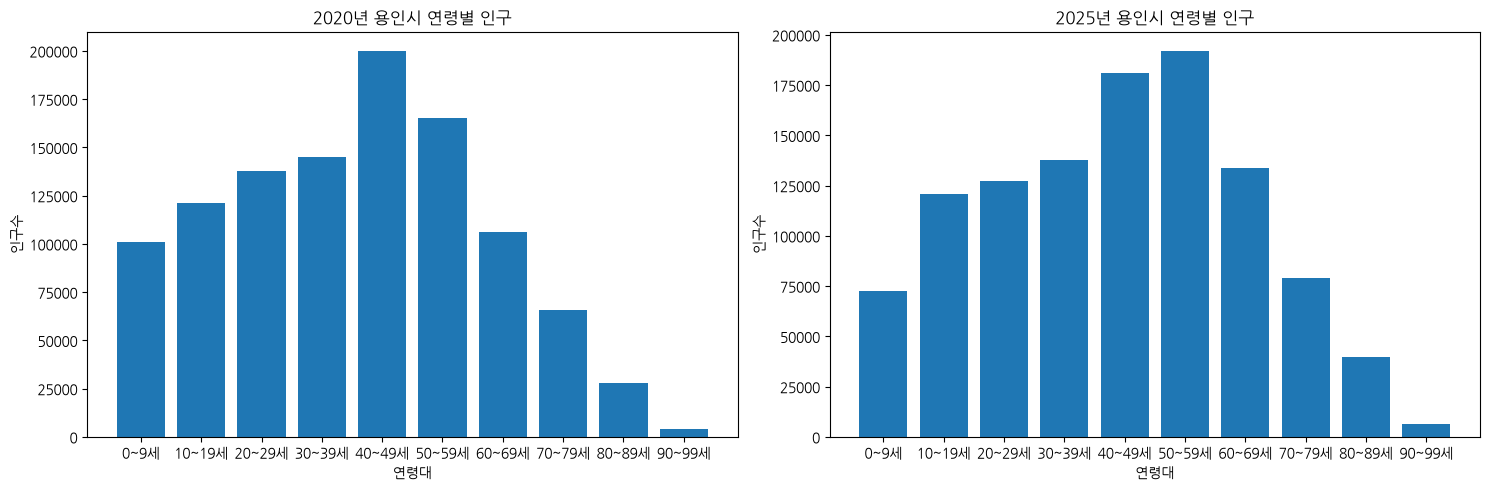

In [68]:
# 연령별 인구수를 바 차트로     # 2020년과 가장 최근인 2025년을 비교
plt.figure(figsize=(15, 5))

# 2020
plt.subplot(1, 2, 1)
plt.bar(
    age_population_2020.index,
    age_population_2020.values
)

plt.xlabel('연령대')
plt.ylabel('인구수')
plt.title('2020년 용인시 연령별 인구')

# 2025
plt.subplot(1, 2, 2)
plt.bar(
    age_population.index,
    age_population.values
)

plt.xlabel('연령대')
plt.ylabel('인구수')
plt.title('2025년 용인시 연령별 인구')

#plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

[분석]
- 0 ~ 9세 아동의 비율이 크게 감소했고 40대 비율이 소폭 감소, 그리고 그 이후 연령대가 꾸준히 상승 중
- 고령화가 꾸준히 진행되고 있음
- bar chart 2개를 나열해놓고 비교하는 것은 직관적이지 않음

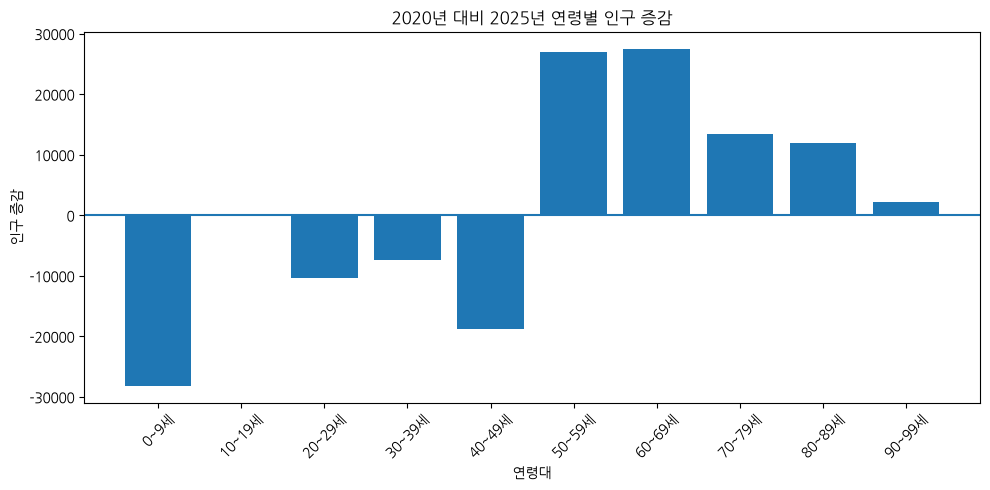

In [70]:
# 어떤 연령층이 얼만큼 변화하였는가?

age_change = age_population - age_population_2020

plt.figure(figsize=(10, 5))

plt.bar(
    age_change.index,
    age_change.values
)

plt.axhline(0)

plt.xlabel('연령대')
plt.ylabel('인구 증감')
plt.title('2020년 대비 2025년 연령별 인구 증감')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

[분석]
- 위에서 분석했던대로 아동의 수가 큰 폭으로 감소, 50대 이후부터 상승하기 시작
- 10대는 유의미한 변화를 보이지 않음

### 연령 평균 비교

In [53]:
# 연령대 정의
age_groups = [
    '0~9세',
    '10~19세',
    '20~29세',
    '30~39세',
    '40~49세',
    '50~59세',
    '60~69세',
    '70~79세',
    '80~89세',
    '90~99세',
    '100세 이상'
]

age_midpoints = [
    4.5,
    14.5,
    24.5,
    34.5,
    44.5,
    54.5,
    64.5,
    74.5,
    84.5,
    94.5,
    100
]

In [54]:
age_data = df_age.loc['경기도 용인시 (4146000000)']

In [55]:
# 연도별 계산
years = range(2020, 2026)

average_ages = []

for year in years:

    populations = []

    for age_group in age_groups:
        value = age_data[f'{year}년_계_{age_group}']

        value = int(str(value).replace(',', ''))
        populations.append(value)

    # 가중치
    weighted_sum = sum(
        age * population
        for age, population in zip(age_midpoints, populations)
    )

    total_population_age = sum(populations)

    average_age = weighted_sum / total_population_age

    average_ages.append(average_age)

average_ages

[40.03492863366897,
 40.66449529841078,
 41.301904423468166,
 41.963362545859574,
 42.51673275843015,
 43.059900420276655]

In [56]:
# 시각화를 위해 dataframe화
df_average_age = pd.DataFrame({
    '연도': list(years),
    '평균연령': average_ages
})

df_average_age

,연도,평균연령
0,2020,40.034929
1,2021,40.664495
2,2022,41.301904
3,2023,41.963363
4,2024,42.516733
5,2025,43.059900


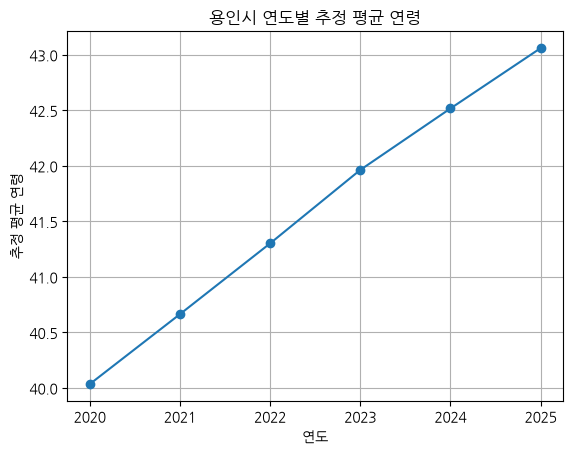

In [57]:
plt.plot(
    df_average_age['연도'],
    df_average_age['평균연령'],
    marker='o'
)

plt.xlabel('연도')
plt.ylabel('추정 평균 연령')
plt.title('용인시 연도별 추정 평균 연령')

plt.grid()
plt.show()

### 행정구역 별 인구증감

In [77]:
# 읍·면·동 행정구역만 추출하는 함수
def extract_by_district(df):
    mask = df.index.to_series().str.contains(
        r'(?:읍|면|동)\s*\(\d+\)\s*$',
        regex=True
    )

    return df.loc[mask].copy()

In [78]:
df_population_emd = extract_by_district(df_population_dist)
df_population_change_emd = extract_by_district(df_population_change_dist)
df_population_by_age_emd = extract_by_district(df_age)

df_population_emd.tail()

,2020년_총인구수,2020년_세대수,2020년_세대당 인구,2020년_남자 인구수,2020년_여자 인구수,2020년_남여 비율,2021년_총인구수,2021년_세대수,2021년_세대당 인구,2021년_남자 인구수,...,2024년_세대당 인구,2024년_남자 인구수,2024년_여자 인구수,2024년_남여 비율,2025년_총인구수,2025년_세대수,2025년_세대당 인구,2025년_남자 인구수,2025년_여자 인구수,2025년_남여 비율
행정구역,,,,,,,,,,,,,,,,,,,,,
경기도 용인시 수지구 동천동(4146556000),49521,18877,2.62,24413,25108,0.97,49723.0,19117.0,2.60,24478.0,...,2.59,24816.0,25781.0,0.96,50787.0,19711.0,2.58,24887.0,25900.0,0.96
경기도 용인시 수지구 상현1동(4146557000),48649,17711,2.75,23535,25114,0.94,20422.0,6754.0,3.02,9775.0,...,3.04,9597.0,10363.0,0.93,19740.0,6534.0,3.02,9413.0,10327.0,0.91
경기도 용인시 수지구 상현2동(4146558000),34092,11698,2.91,16604,17488,0.95,33287.0,11528.0,2.89,16158.0,...,2.87,15918.0,16956.0,0.94,32659.0,11413.0,2.86,15811.0,16848.0,0.94
경기도 용인시 수지구 상현3동(4146558500),0,0,0.00,0,0,0.00,27895.0,11114.0,2.51,13488.0,...,2.47,13241.0,14239.0,0.93,27231.0,11096.0,2.45,13133.0,14098.0,0.93
경기도 용인시 수지구 성복동(4146559000),51552,17758,2.90,24773,26779,0.93,54604.0,18805.0,2.90,26316.0,...,2.91,26320.0,28347.0,0.93,54421.0,18723.0,2.91,26175.0,28246.0,0.93


In [ ]:
population_change_district = df_population_emd[
    ['2020년_총인구수', '2025년_총인구수']
].copy()

In [80]:
# , 명 이런 문자들이 포함되어 있다면 제거
for col in ['2020년_총인구수', '2025년_총인구수']:
    population_change_district[col] = pd.to_numeric(
        population_change_district[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('명', '', regex=False)
        .str.strip(),
        errors='coerce'
    )

In [81]:
population_change_district.head()

,2020년_총인구수,2025년_총인구수
행정구역,,
경기도 용인시 처인구 포곡읍(4146125000),33300,30848.0
경기도 용인시 처인구 모현읍(4146125300),26202,34384.0
경기도 용인시 처인구 이동읍(4146125600),20265,19018.0
경기도 용인시 처인구 남사읍(4146125900),0,23561.0
경기도 용인시 처인구 남사면(4146132000),23547,NaN


In [82]:
# 컬럼 이름이 너무 길어
population_change_district = population_change_district.rename(
    columns={
        '2020년_총인구수': '2020인구',
        '2025년_총인구수': '2025인구'
    }
)

population_change_district.head()

,2020인구,2025인구
행정구역,,
경기도 용인시 처인구 포곡읍(4146125000),33300,30848.0
경기도 용인시 처인구 모현읍(4146125300),26202,34384.0
경기도 용인시 처인구 이동읍(4146125600),20265,19018.0
경기도 용인시 처인구 남사읍(4146125900),0,23561.0
경기도 용인시 처인구 남사면(4146132000),23547,NaN


In [95]:
# 증감 게산         # 변수명이 너무 긴가?
population_change_district['증감인원'] = (
    population_change_district['2025인구']
    - population_change_district['2020인구']
)

# 정상적으로 증감률을 계산할 수 있는 조건
# 0이나 NaN이 섞여 있으면 명확한 데이터 계산 불가
valid = (
    population_change_district['2020인구'].notna()
    & population_change_district['2025인구'].notna()
    & (population_change_district['2020인구'] > 0)
)

# 유효한 지역만 증감률 계산
population_change_district['증감률'] = np.where(
    valid,
    population_change_district['증감인원']
    / population_change_district['2020인구']
    * 100,
    np.nan
)

population_change_district['증감률'] = (
    population_change_district['증감률'].round(2)
)
population_change_district.head()

,2020인구,2025인구,증감인원,증감률
행정구역,,,,
경기도 용인시 처인구 포곡읍(4146125000),33300,30848.0,-2452.0,-7.36
경기도 용인시 처인구 모현읍(4146125300),26202,34384.0,8182.0,31.23
경기도 용인시 처인구 이동읍(4146125600),20265,19018.0,-1247.0,-6.15
경기도 용인시 처인구 남사읍(4146125900),0,23561.0,23561.0,NaN
경기도 용인시 처인구 남사면(4146132000),23547,NaN,NaN,NaN


In [99]:
# dataframe에 신설이나 분할, 폐동과 같은 상태가 예상되는 지 여부를 추가
population_change_district['상태'] = np.select(
    [
        # 2020년에는 없었는데 2025년에는 존재
        (
            (population_change_district['2020인구'].isna()
             | (population_change_district['2020인구'] == 0))
            & (population_change_district['2025인구'] > 0)
        ),

        # 2020년에는 있었는데 2025년에는 없거나 0
        (
            (population_change_district['2020인구'] > 0)
            & (
                population_change_district['2025인구'].isna()
                | (population_change_district['2025인구'] == 0)
            )
        ),

        # 두 연도 모두 정상적인 값
        (
            (population_change_district['2020인구'] > 0)
            & (population_change_district['2025인구'] > 0)
        )
    ],
    [
        '신설/분동 후보',
        '폐지/통합 후보',
        '비교 가능'
    ],
    default='확인 필요'
)

population_change_district.head()

,2020인구,2025인구,증감인원,증감률,상태
행정구역,,,,,
경기도 용인시 처인구 포곡읍(4146125000),33300,30848.0,-2452.0,-7.36,비교 가능
경기도 용인시 처인구 모현읍(4146125300),26202,34384.0,8182.0,31.23,비교 가능
경기도 용인시 처인구 이동읍(4146125600),20265,19018.0,-1247.0,-6.15,비교 가능
경기도 용인시 처인구 남사읍(4146125900),0,23561.0,23561.0,NaN,신설/분동 후보
경기도 용인시 처인구 남사면(4146132000),23547,NaN,NaN,NaN,폐지/통합 후보


In [100]:
# 증감률 기준으로 정렬
population_change_district.sort_values(
    '증감률',
    ascending=False
).head(10)

,2020인구,2025인구,증감인원,증감률,상태
행정구역,,,,,
경기도 용인시 처인구 모현읍(4146125300),26202,34384.0,8182.0,31.23,비교 가능
경기도 용인시 기흥구 동백3동(4146357700),23521,27271.0,3750.0,15.94,비교 가능
경기도 용인시 처인구 양지면(4146136000),19084,21455.0,2371.0,12.42,비교 가능
경기도 용인시 기흥구 영덕1동(4146351600),30729,34208.0,3479.0,11.32,비교 가능
경기도 용인시 처인구 중앙동(4146151000),24635,26885.0,2250.0,9.13,비교 가능
경기도 용인시 기흥구 영덕2동(4146351700),17623,19137.0,1514.0,8.59,비교 가능
경기도 용인시 수지구 신봉동(4146553000),38172,41065.0,2893.0,7.58,비교 가능
경기도 용인시 수지구 성복동(4146559000),51552,54421.0,2869.0,5.57,비교 가능
경기도 용인시 기흥구 마북동(4146357000),32392,33584.0,1192.0,3.68,비교 가능


In [101]:
# 증감 인원 기준으로 정렬
population_change_district.sort_values(
    '증감인원',
    ascending=False
).head(10)

,2020인구,2025인구,증감인원,증감률,상태
행정구역,,,,,
경기도 용인시 처인구 유림2동(4146153600),0,38396.0,38396.0,NaN,신설/분동 후보
경기도 용인시 처인구 역북동(4146152500),0,34727.0,34727.0,NaN,신설/분동 후보
경기도 용인시 수지구 상현3동(4146558500),0,27231.0,27231.0,NaN,신설/분동 후보
경기도 용인시 수지구 죽전3동(4146555500),0,26294.0,26294.0,NaN,신설/분동 후보
경기도 용인시 처인구 남사읍(4146125900),0,23561.0,23561.0,NaN,신설/분동 후보
경기도 용인시 처인구 유림1동(4146153500),0,13538.0,13538.0,NaN,신설/분동 후보
경기도 용인시 처인구 삼가동(4146152600),0,11941.0,11941.0,NaN,신설/분동 후보
경기도 용인시 처인구 모현읍(4146125300),26202,34384.0,8182.0,31.23,비교 가능
경기도 용인시 기흥구 동백3동(4146357700),23521,27271.0,3750.0,15.94,비교 가능


[분석]
- 구역별 인구 증감은 위 자료만으로 파악할 수 없음 행정구역의 통폐합, 추가신설 등의 요소가 있어 인구가 크게 변동하는 구역이 있기 때문

In [102]:
# 비교 가능한 구역만 추출
valid_district = population_change_district[
    (population_change_district['2020인구'] > 0)
    & (population_change_district['2025인구'] > 0)
].copy()

valid_district.sort_values(
    '증감인원',
    ascending=False
).head(10)

,2020인구,2025인구,증감인원,증감률,상태
행정구역,,,,,
경기도 용인시 처인구 모현읍(4146125300),26202,34384.0,8182.0,31.23,비교 가능
경기도 용인시 기흥구 동백3동(4146357700),23521,27271.0,3750.0,15.94,비교 가능
경기도 용인시 기흥구 영덕1동(4146351600),30729,34208.0,3479.0,11.32,비교 가능
경기도 용인시 수지구 신봉동(4146553000),38172,41065.0,2893.0,7.58,비교 가능
경기도 용인시 수지구 성복동(4146559000),51552,54421.0,2869.0,5.57,비교 가능
경기도 용인시 처인구 양지면(4146136000),19084,21455.0,2371.0,12.42,비교 가능
경기도 용인시 처인구 중앙동(4146151000),24635,26885.0,2250.0,9.13,비교 가능
경기도 용인시 기흥구 영덕2동(4146351700),17623,19137.0,1514.0,8.59,비교 가능
경기도 용인시 수지구 동천동(4146556000),49521,50787.0,1266.0,2.56,비교 가능


In [103]:
# 정렬 된 데이터를 새로운 df에
district_sorted = valid_district.sort_values(
    '증감률',
    ascending=True
)

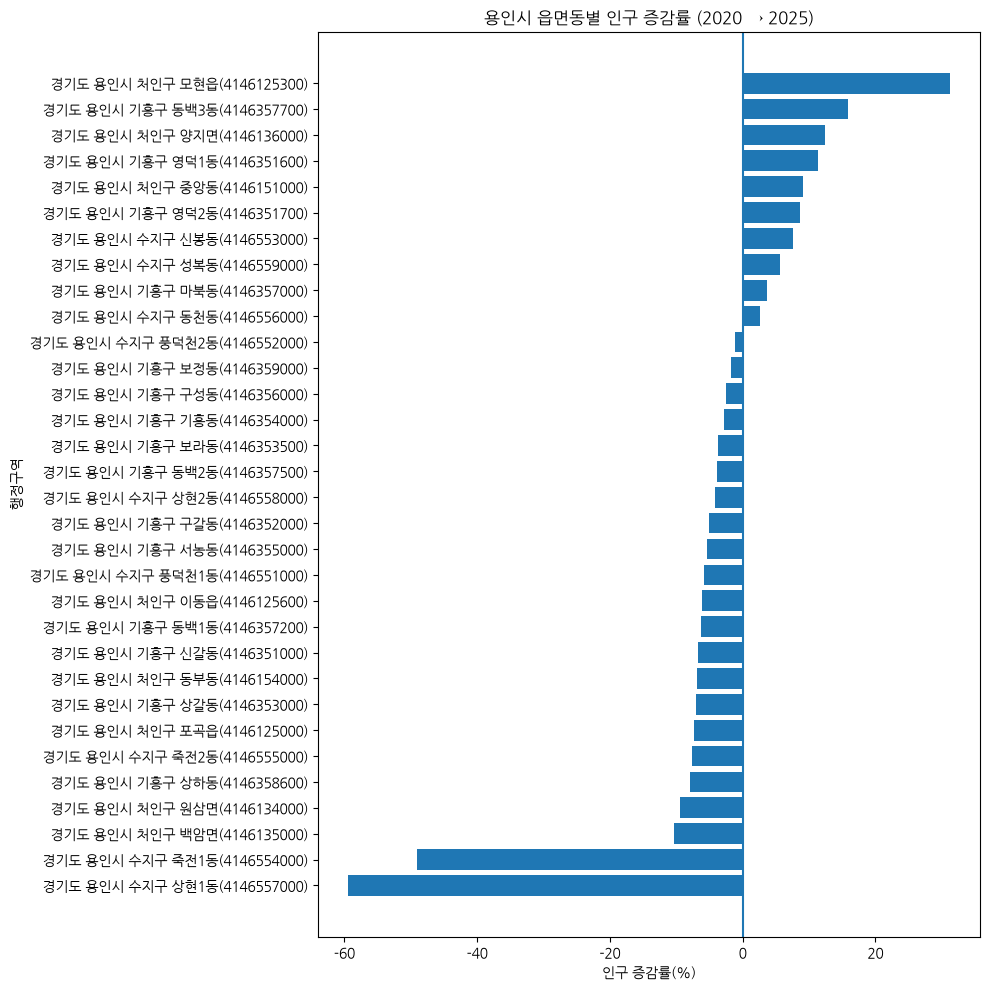

In [104]:
plt.figure(figsize=(10, 10))

plt.barh(
    district_sorted.index,
    district_sorted['증감률']
)

# 증가/감소 기준선
plt.axvline(0)

plt.xlabel('인구 증감률(%)')
plt.ylabel('행정구역')
plt.title('용인시 읍면동별 인구 증감률 (2020 → 2025)')

plt.tight_layout()
plt.show()

In [105]:
# 너무 많으면 상위, 하위 10개씩 보여주기
top_increase = valid_district.nlargest(10, '증감률')
top_decrease = valid_district.nsmallest(10, '증감률')

district_top20 = pd.concat([
    top_decrease,
    top_increase
]).sort_values('증감률')

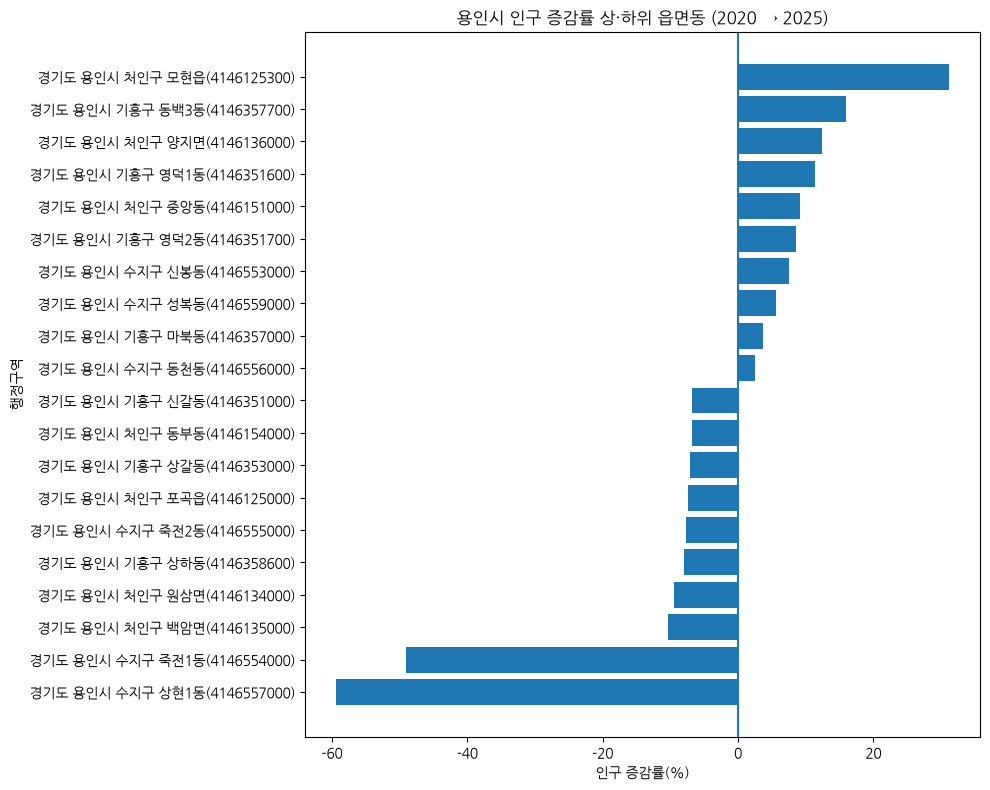

In [106]:
plt.figure(figsize=(10, 8))

plt.barh(
    district_top20.index,
    district_top20['증감률']
)

plt.axvline(0)

plt.xlabel('인구 증감률(%)')
plt.ylabel('행정구역')
plt.title('용인시 인구 증감률 상·하위 읍면동 (2020 → 2025)')

plt.tight_layout()
plt.show()

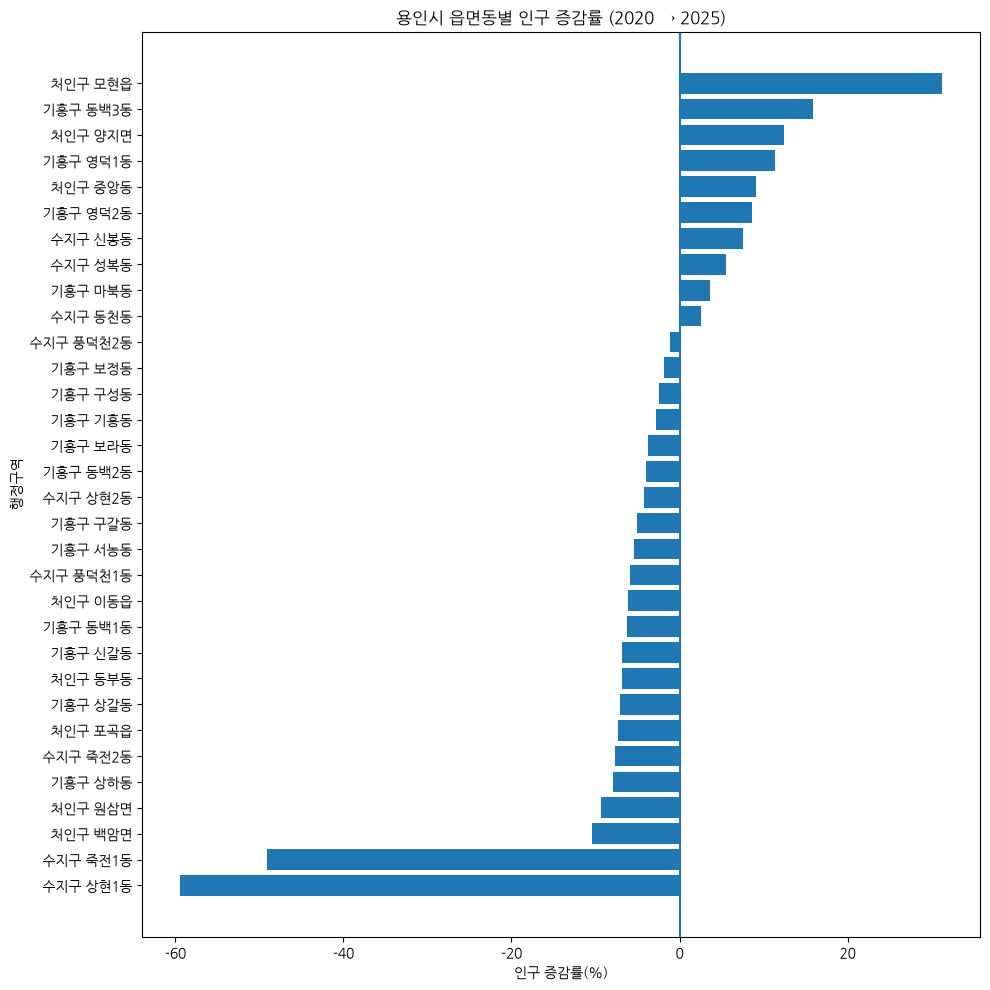

In [107]:
# 경기도 용인시 내부 데이터라 '경기도 용인시' 단어나 뒤의 행정구역번호는 필요가 없다
plt.figure(figsize=(10, 10))

district_labels = (
    district_sorted.index
    .to_series()
    .str.replace(r'^경기도\s+용인시\s+', '', regex=True)
    .str.replace(r'\(\d+\)\s*$', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

plt.barh(
    district_labels,
    district_sorted['증감률']
)

plt.axvline(0)

plt.xlabel('인구 증감률(%)')
plt.ylabel('행정구역')
plt.title('용인시 읍면동별 인구 증감률 (2020 → 2025)')

plt.tight_layout()
plt.show()

[분석]
- 사실 위 데이터만으로는 구역별 인구 증감을 명확하게 파악할 수 없음
- 행정구역의 통폐합, 추가 신설 등으로 데이터가 오염되는 것은 마찬가지
- 데이터를 정제하는 것 뿐 아니라, 다른 데이터를 추가해서 다양한 자료를 통해 관점을 늘려야함

### 관련 기사
[2022년 인구 감소 원인]
- https://www.yongin21.co.kr/news/articleView.html?idxno=75292&
- 단, 위 기사만으로는 명확한 근거라고 할 수 없음
- 인구 감소보다는 유입 감소라고 보는게 타당(순유출)

[2024년 인구 증가 원인]
- https://www.yna.co.kr/view/AKR20240516077300061

[행정구역 별 인구 증감 원인 및 행정구역 변경]
- https://www.yongin21.co.kr/news/articleView.html?idxno=79394&
- https://www.yongin21.co.kr/news/articleView.html?idxno=80056&

[고령화]
- https://www.yna.co.kr/view/AKR20230130059400061
- https://www.yongin21.co.kr/news/articleView.html?idxno=73996
- 인구 증가가 곧 청년 인구 상승이라고 볼 수는 없음

### 제안 정책

- 용인시의 인구는 증가 추세
- 인구는 증가하고 있으나 청년 이하 인구는 감소 추세
- 주택 및 산업단지 조성으로 인구는 증가 -> 이를 유지할 정책 필요